## Cell 1 — Imports and Dependencies

Imports all required libraries including PyTorch, torchvision, Albumentations, scikit-learn, and standard utilities. Run this cell first before any other cell in the notebook.

In [1]:
import os
import sys
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from collections import Counter
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR, ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast

# Torchvision imports
import torchvision
from torchvision import transforms
from torchvision.models import resnet101, ResNet101_Weights
from torchvision.ops import FeaturePyramidNetwork
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Scikit-learn for metrics and utilities
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# Suppress warnings
warnings.filterwarnings('ignore')

## Cell 2 — Seed and Device Setup

Sets global random seeds for full reproducibility across Python, NumPy, and PyTorch. Detects and prints the available compute device (GPU or CPU) that will be used for training.

In [2]:
def set_seed(seed: int = 42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"📊 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


🖥️  Using device: cuda
📊 GPU: NVIDIA GeForce RTX 3060
💾 GPU Memory: 12.88 GB


## Cell 3 — Configuration Parameters

Defines the central `Config` class holding all hyperparameters and directory paths for the training pipeline. Creates the output, checkpoint, and log directories if they do not already exist.

In [3]:
# CELL 3: CONFIGURATION PARAMETERS
# ============================================================================
class Config:
    """Central configuration for the training pipeline."""
    
    # Paths
    DATA_ROOT = Path("../../dataset/Raw_dataset")
    OUTPUT_DIR = Path("outputs")
    CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
    LOG_DIR = OUTPUT_DIR / "logs"
    
    # Dataset parameters
    CLASSES = ['Healthy', 'Anthracnose']
    NUM_CLASSES = 2
    PLANTS = ['Guava', 'Mango', 'Papaya']
    
    # Image parameters
    IMG_SIZE = 224
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD = [0.229, 0.224, 0.225]
    
    # Training parameters
    BATCH_SIZE = 24
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    
    # Scheduler parameters
    WARMUP_EPOCHS = 5
    MIN_LR = 1e-7
    
    # Early stopping
    PATIENCE = 15
    MIN_DELTA = 1e-4
    
    # Data split
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # Augmentation probability
    AUG_PROB = 0.5
    
    # Label smoothing
    LABEL_SMOOTHING = 0.1
    
    # Mixup/Cutmix
    MIXUP_ALPHA = 0.2
    CUTMIX_ALPHA = 1.0
    MIXUP_PROB = 0.3
    
    # Model architecture
    FPN_CHANNELS = 256
    GCA_REDUCTION = 16
    DROPOUT_RATE = 0.3
    
    # Mask R-CNN (for segmentation branch)
    MASK_RCNN_SCORE_THRESH = 0.5
    
    # Logging
    LOG_INTERVAL = 10
    
    @classmethod
    def create_dirs(cls):
        """Create output directories."""
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        cls.CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        cls.LOG_DIR.mkdir(parents=True, exist_ok=True)
        print("✅ Output directories created")

# Create directories
Config.create_dirs()

# Display configuration
print("\n📋 Configuration Summary:")
print(f"   - Image Size: {Config.IMG_SIZE}x{Config.IMG_SIZE}")
print(f"   - Batch Size: {Config.BATCH_SIZE}")
print(f"   - Learning Rate: {Config.LEARNING_RATE}")
print(f"   - Epochs: {Config.NUM_EPOCHS}")
print(f"   - Label Smoothing: {Config.LABEL_SMOOTHING}")
print(f"   - Mixup Alpha: {Config.MIXUP_ALPHA}")

✅ Output directories created

📋 Configuration Summary:
   - Image Size: 224x224
   - Batch Size: 24
   - Learning Rate: 0.0001
   - Epochs: 100
   - Label Smoothing: 0.1
   - Mixup Alpha: 0.2


## Cell 4 — Dataset Loader

Defines `DatasetLoader`, which scans the dataset directory for images organised by plant type and disease class. Run once after configuration to obtain the full image inventory as a pandas DataFrame.

✅ Loaded 5072 images from 6 folders

📊 Dataset Statistics:
class   Anthracnose  Healthy
plant                       
Guava           237     1248
Mango          1100     1100
Papaya          585      802

📈 Overall Class Distribution:
class
Healthy        3150
Anthracnose    1922
Name: count, dtype: int64


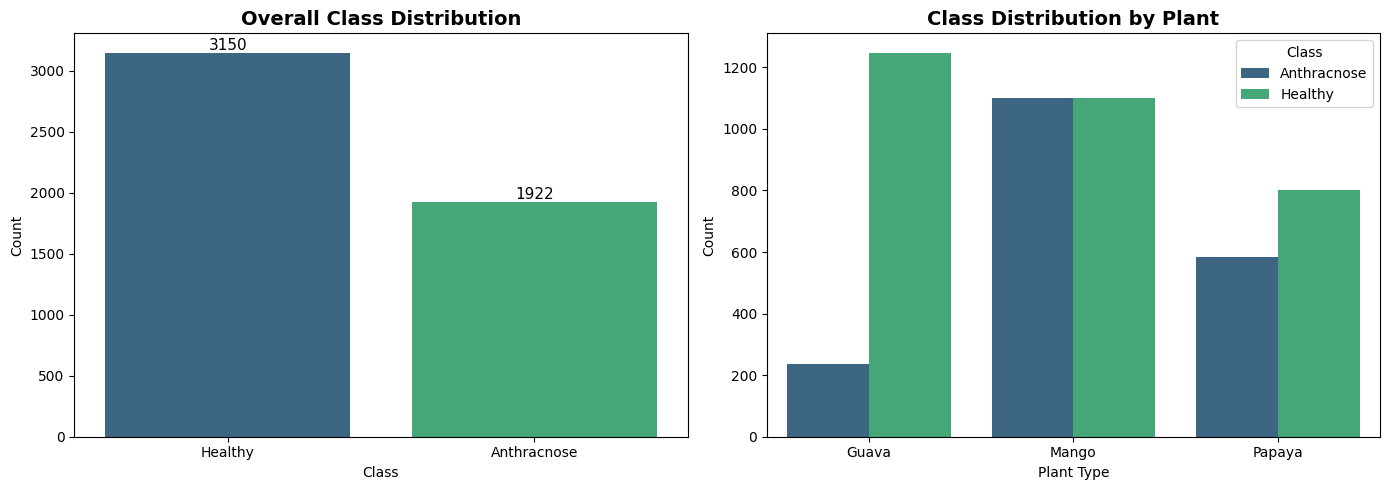

In [4]:
class DatasetLoader:
    """Load and organize the dataset with class labels."""
    
    def __init__(self, data_root: Path, plants: List[str], classes: List[str]):
        self.data_root = data_root
        self.plants = plants
        self.classes = classes
        
    def load_dataset(self) -> pd.DataFrame:
        """Load all images and their labels into a DataFrame."""
        data = []
        
        for plant in self.plants:
            for cls in self.classes:
                folder_name = f"{plant}_{cls}"
                folder_path = self.data_root / folder_name
                
                if not folder_path.exists():
                    print(f"⚠️  Warning: {folder_path} not found")
                    continue
                
                # Get all image files
                image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
                for img_path in folder_path.iterdir():
                    if img_path.suffix.lower() in image_extensions:
                        data.append({
                            'image_path': str(img_path),
                            'plant': plant,
                            'class': cls,
                            'label': 0 if cls == 'Healthy' else 1,
                            'folder': folder_name
                        })
        
        df = pd.DataFrame(data)
        print(f"✅ Loaded {len(df)} images from {len(df['folder'].unique())} folders")
        return df
    
    @staticmethod
    def compute_class_weights(labels: np.ndarray) -> torch.Tensor:
        """Compute class weights for imbalanced datasets."""
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(labels),
            y=labels
        )
        return torch.tensor(class_weights, dtype=torch.float32)
    
    @staticmethod
    def get_sample_weights(labels: np.ndarray) -> np.ndarray:
        """Get per-sample weights for WeightedRandomSampler."""
        class_counts = Counter(labels)
        total = len(labels)
        class_weights = {cls: total / count for cls, count in class_counts.items()}
        sample_weights = np.array([class_weights[label] for label in labels])
        return sample_weights

# Load dataset
loader = DatasetLoader(Config.DATA_ROOT, Config.PLANTS, Config.CLASSES)
df = loader.load_dataset()

# Display dataset statistics
print("\n📊 Dataset Statistics:")
print(df.groupby(['plant', 'class']).size().unstack(fill_value=0))

# Class distribution
print("\n📈 Overall Class Distribution:")
print(df['class'].value_counts())

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.countplot(data=df, x='class', ax=axes[0], palette='viridis')
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Per-plant distribution
df_melted = df.groupby(['plant', 'class']).size().reset_index(name='count')
sns.barplot(data=df_melted, x='plant', y='count', hue='class', ax=axes[1], palette='viridis')
axes[1].set_title('Class Distribution by Plant', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Plant Type')
axes[1].set_ylabel('Count')
axes[1].legend(title='Class')

plt.tight_layout()
plt.savefig(Config.OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Stratified Data Split

Splits the full dataset into train (70 %), validation (15 %), and test (15 %) subsets while preserving class and plant-type distribution. Run after loading the dataset.

In [5]:
def stratified_split(df: pd.DataFrame, 
                     train_ratio: float = 0.7,
                     val_ratio: float = 0.15,
                     test_ratio: float = 0.15,
                     random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Perform stratified split maintaining class balance across splits.
    Stratifies by both plant type and class to ensure representative splits.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    
    # Create stratification column
    df['strat_col'] = df['plant'] + '_' + df['class']
    
    # First split: train vs (val + test)
    train_df, temp_df = train_test_split(
        df,
        test_size=(val_ratio + test_ratio),
        stratify=df['strat_col'],
        random_state=random_state
    )
    
    # Second split: val vs test
    relative_test_ratio = test_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_ratio,
        stratify=temp_df['strat_col'],
        random_state=random_state
    )
    
    # Remove stratification column
    for split_df in [train_df, val_df, test_df]:
        split_df.drop('strat_col', axis=1, inplace=True)
    
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

# Perform split
train_df, val_df, test_df = stratified_split(
    df, 
    Config.TRAIN_RATIO, 
    Config.VAL_RATIO, 
    Config.TEST_RATIO
)

print("📊 Split Statistics:")
print(f"   Training:   {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Validation: {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:       {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

# Verify class balance in splits
print("\n📈 Class Distribution in Splits:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['class'].value_counts()
    print(f"   {name}: Healthy={dist.get('Healthy', 0)}, Anthracnose={dist.get('Anthracnose', 0)}")

# Compute class weights from training set
train_labels = train_df['label'].values
class_weights = DatasetLoader.compute_class_weights(train_labels)
sample_weights = DatasetLoader.get_sample_weights(train_labels)

print(f"\n⚖️  Class Weights: {class_weights.tolist()}")
print(f"   (Higher weight = more focus on minority class)")

# Save splits for reproducibility
train_df.to_csv(Config.OUTPUT_DIR / 'train_split.csv', index=False)
val_df.to_csv(Config.OUTPUT_DIR / 'val_split.csv', index=False)
test_df.to_csv(Config.OUTPUT_DIR / 'test_split.csv', index=False)
print("\n✅ Splits saved to output directory")

📊 Split Statistics:
   Training:   3550 samples (70.0%)
   Validation: 761 samples (15.0%)
   Test:       761 samples (15.0%)

📈 Class Distribution in Splits:
   Train: Healthy=2205, Anthracnose=1345
   Val: Healthy=473, Anthracnose=288
   Test: Healthy=472, Anthracnose=289

⚖️  Class Weights: [0.80498868227005, 1.3197026252746582]
   (Higher weight = more focus on minority class)

✅ Splits saved to output directory


## Cell 6 — Augmentation Pipeline

Defines the `AugmentationPipeline` class with separate transforms for training (7 augmentations including rotation, elastic deformation, and colour jitter) and validation (resize + normalise only). Run once to make the pipelines available.

In [6]:
class AugmentationPipeline:
    """Comprehensive augmentation pipeline for training."""
    
    @staticmethod
    def get_train_transforms(img_size: int = 224, aug_prob: float = 0.5) -> A.Compose:
        """
        Training augmentation pipeline with 5+ augmentations.
        Applied only during training to improve generalization.
        """
        return A.Compose([
            # 1. Random Rotation (±30 degrees)
            A.Rotate(limit=30, p=aug_prob, border_mode=cv2.BORDER_REFLECT_101),
            
            # 2. Horizontal and Vertical Flip
            A.HorizontalFlip(p=aug_prob),
            A.VerticalFlip(p=aug_prob * 0.5),  # Less frequent for leaves
            
            # 3. Brightness and Contrast Jitter
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=aug_prob
            ),
            
            # 4. Random Resized Crop (simulates zoom and crop)
            A.RandomResizedCrop(
                size=(img_size, img_size),
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1),
                p=aug_prob
            ),
            
            # 5. Color Jitter (Hue, Saturation)
            A.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.2,
                hue=0.1,
                p=aug_prob
            ),
            
            # Additional augmentations for robustness
            # 6. Gaussian Blur
            A.GaussianBlur(blur_limit=(3, 7), p=aug_prob * 0.3),
            
            # 7. Random Shadow (simulates outdoor conditions)
            A.RandomShadow(
                shadow_roi=(0, 0.5, 1, 1),
                num_shadows_lower=1,
                num_shadows_upper=2,
                shadow_dimension=5,
                p=aug_prob * 0.3
            ),
            
            # 8. CLAHE (Contrast Limited Adaptive Histogram Equalization)
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=aug_prob * 0.3),
            
            # 9. Coarse Dropout (Random Erasing/Cutout)
            A.CoarseDropout(
                max_holes=8,
                max_height=img_size // 8,
                max_width=img_size // 8,
                min_holes=1,
                min_height=img_size // 16,
                min_width=img_size // 16,
                fill_value=0,
                p=aug_prob * 0.3
            ),
            
            # Final resize to ensure consistent size
            A.Resize(img_size, img_size),
            
            # Normalize and convert to tensor
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    
    @staticmethod
    def get_val_transforms(img_size: int = 224) -> A.Compose:
        """
        Validation/Test transforms - only resize and normalize.
        No augmentation to get consistent evaluation.
        """
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    
    @staticmethod
    def get_visualization_transforms(img_size: int = 224) -> A.Compose:
        """Transforms for visualization (without normalization)."""
        return A.Compose([
            A.Rotate(limit=30, p=1.0, border_mode=cv2.BORDER_REFLECT_101),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0), ratio=(0.9, 1.1), p=1.0),
            A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.1, p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
            A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),
            A.Resize(img_size, img_size),
        ])

# Create transform instances
train_transforms = AugmentationPipeline.get_train_transforms(Config.IMG_SIZE, Config.AUG_PROB)
val_transforms = AugmentationPipeline.get_val_transforms(Config.IMG_SIZE)
vis_transforms = AugmentationPipeline.get_visualization_transforms(Config.IMG_SIZE)

print("✅ Augmentation pipelines created")
print(f"   Training: {len(train_transforms)} transforms")
print(f"   Validation: {len(val_transforms)} transforms")

✅ Augmentation pipelines created
   Training: 13 transforms
   Validation: 3 transforms


## Cell 7 — Augmentation Visualization

Defines `visualize_augmentations` for displaying original and augmented versions of sample images side by side. Call this function after creating the pipeline to verify augmentation behaviour.

🔄 Visualizing augmentation effects...
✅ Visualization saved to outputs\augmentation_visualization.png


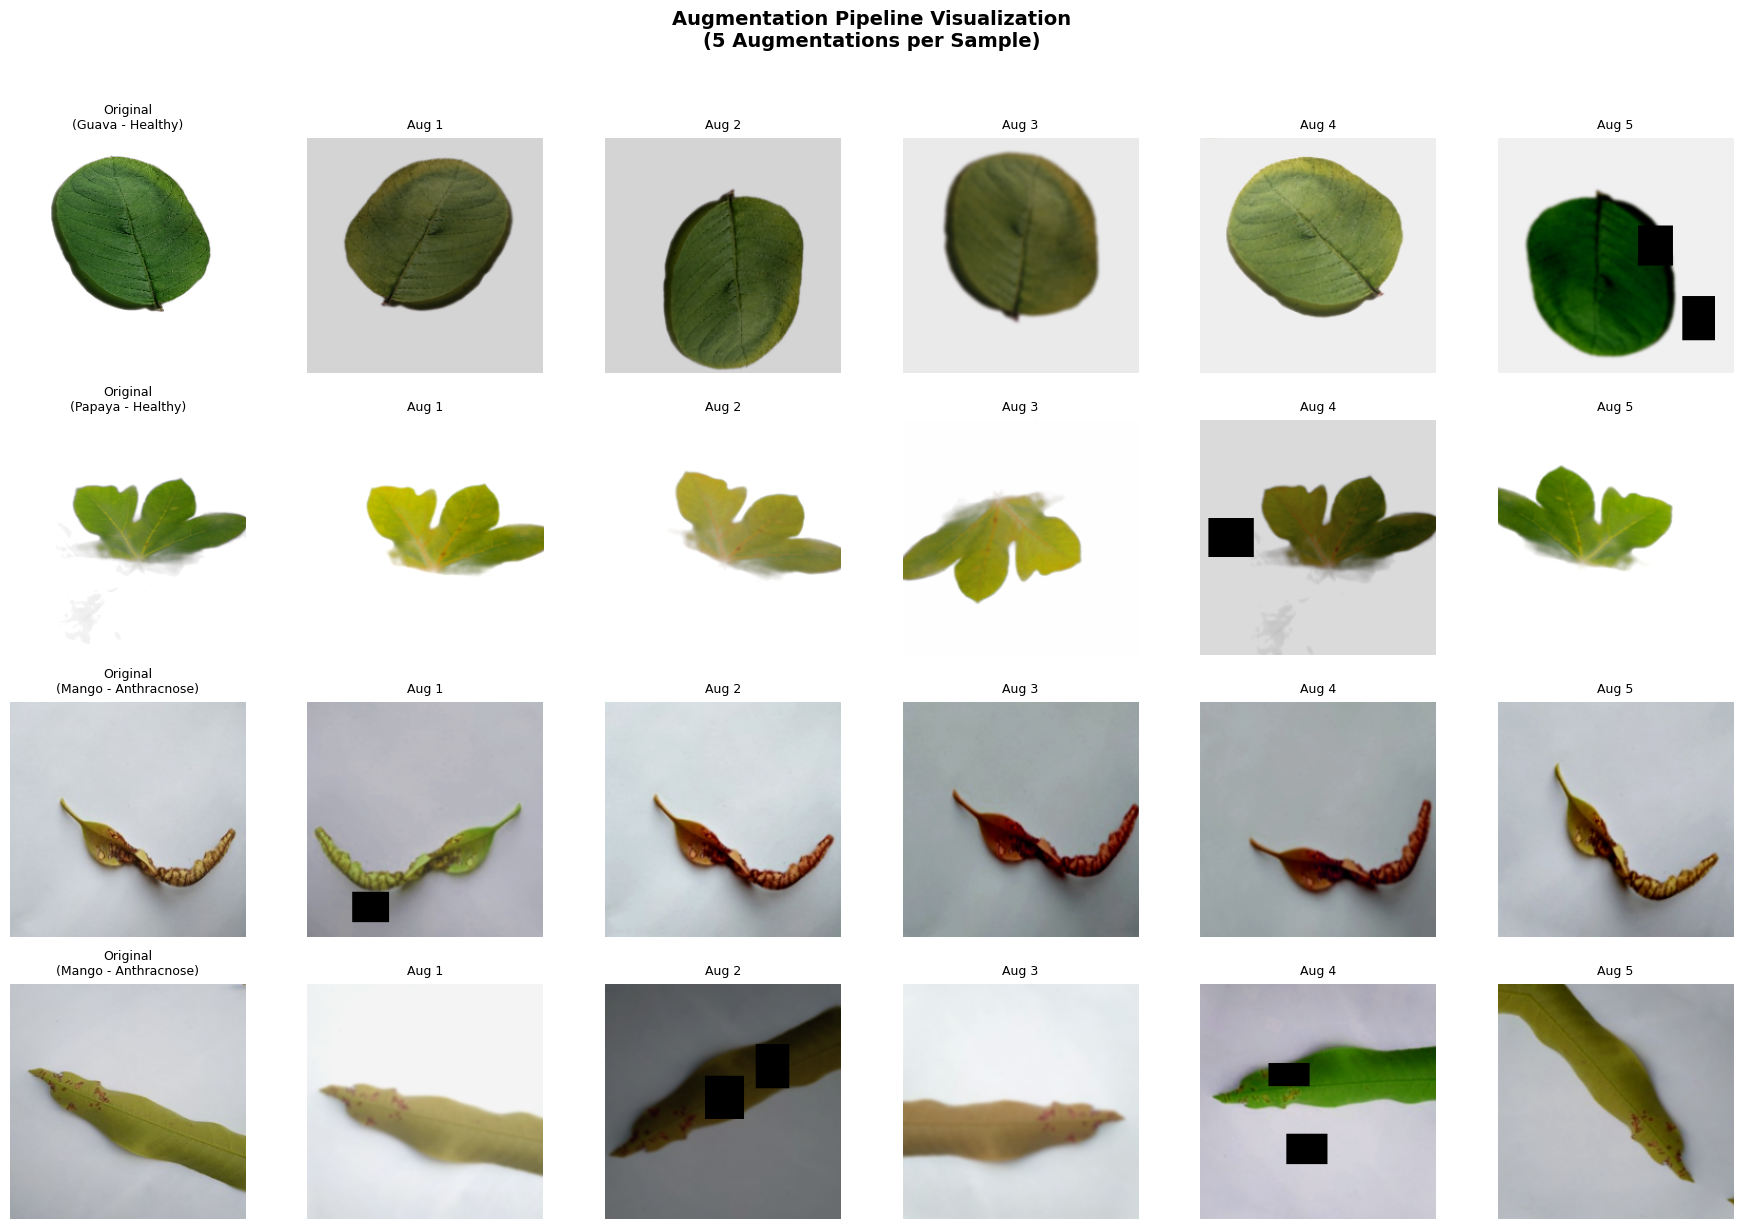

In [7]:
def visualize_augmentations(df: pd.DataFrame, 
                           transforms: A.Compose,
                           num_samples: int = 3,
                           num_augmentations: int = 5,
                           save_path: Optional[Path] = None):
    """
    Visualize augmentation effects on sample images from each class.
    
    Args:
        df: DataFrame with image paths and labels
        transforms: Albumentations transform pipeline
        num_samples: Number of samples per class
        num_augmentations: Number of augmented versions per sample
        save_path: Path to save the visualization
    """
    fig, axes = plt.subplots(
        len(Config.CLASSES) * num_samples, 
        num_augmentations + 1,  # +1 for original
        figsize=(3 * (num_augmentations + 1), 3 * len(Config.CLASSES) * num_samples)
    )
    
    row_idx = 0
    for cls in Config.CLASSES:
        cls_df = df[df['class'] == cls].sample(n=num_samples, random_state=42)
        
        for _, row in cls_df.iterrows():
            # Load original image
            img = cv2.imread(row['image_path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (Config.IMG_SIZE, Config.IMG_SIZE))
            
            # Plot original
            axes[row_idx, 0].imshow(img)
            axes[row_idx, 0].set_title(f'Original\n({row["plant"]} - {cls})', fontsize=9)
            axes[row_idx, 0].axis('off')
            
            # Plot augmented versions
            for aug_idx in range(num_augmentations):
                augmented = transforms(image=img)['image']
                axes[row_idx, aug_idx + 1].imshow(augmented)
                axes[row_idx, aug_idx + 1].set_title(f'Aug {aug_idx + 1}', fontsize=9)
                axes[row_idx, aug_idx + 1].axis('off')
            
            row_idx += 1
    
    plt.suptitle('Augmentation Pipeline Visualization\n(5 Augmentations per Sample)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Visualization saved to {save_path}")
    
    plt.show()

# Visualize augmentations for both classes
print("🔄 Visualizing augmentation effects...")
visualize_augmentations(
    train_df, 
    vis_transforms,
    num_samples=2,
    num_augmentations=5,
    save_path=Config.OUTPUT_DIR / 'augmentation_visualization.png'
)

## Cell 8 — Individual Augmentation Demo

Defines `demonstrate_individual_augmentations` to display the effect of each of the five main augmentations on a single image. Useful for visually confirming augmentation parameters before training.

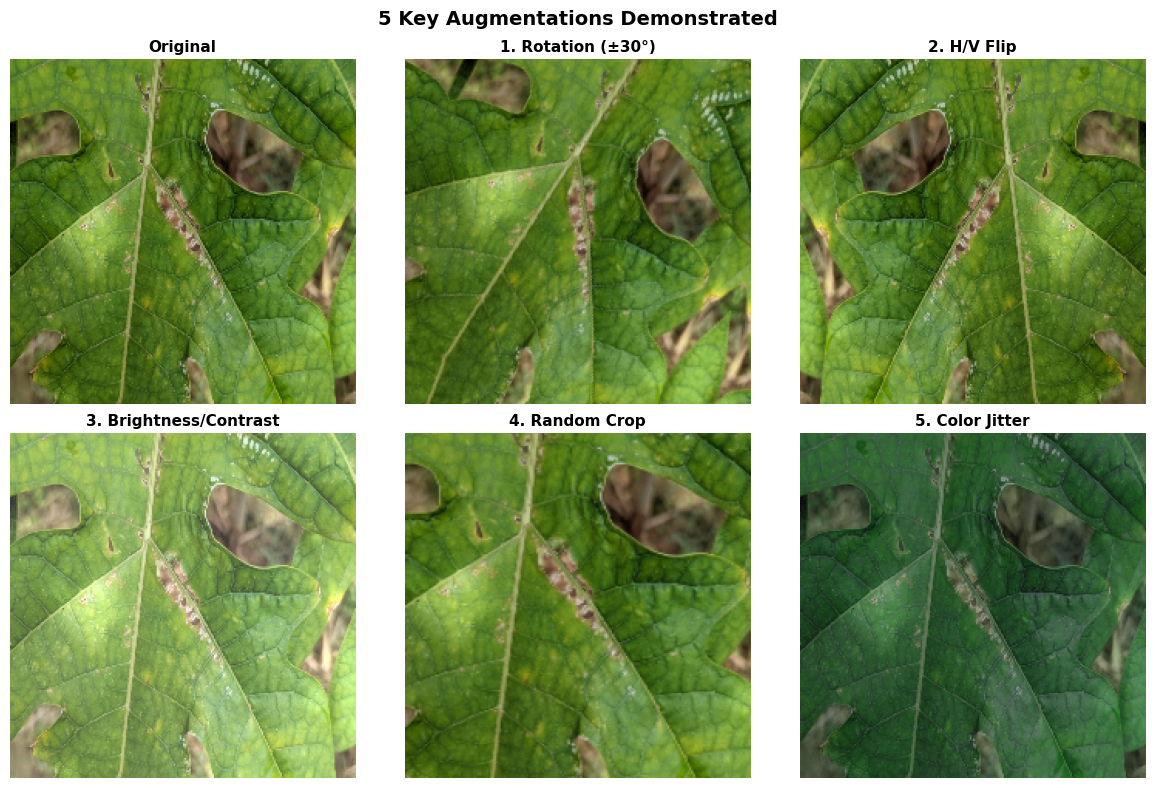

In [8]:
def demonstrate_individual_augmentations(image_path: str, save_path: Optional[Path] = None):
    """
    Demonstrate each of the 5 main augmentations individually.
    """
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (Config.IMG_SIZE, Config.IMG_SIZE))
    
    # Define individual augmentations
    augmentations = {
        'Original': A.Compose([A.Resize(Config.IMG_SIZE, Config.IMG_SIZE)]),
        '1. Rotation (±30°)': A.Compose([
            A.Rotate(limit=30, p=1.0, border_mode=cv2.BORDER_REFLECT_101),
            A.Resize(Config.IMG_SIZE, Config.IMG_SIZE)
        ]),
        '2. H/V Flip': A.Compose([
            A.HorizontalFlip(p=1.0),
            A.Resize(Config.IMG_SIZE, Config.IMG_SIZE)
        ]),
        '3. Brightness/Contrast': A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
            A.Resize(Config.IMG_SIZE, Config.IMG_SIZE)
        ]),
        '4. Random Crop': A.Compose([
            A.RandomResizedCrop(size=(Config.IMG_SIZE, Config.IMG_SIZE), scale=(0.7, 0.9), p=1.0)
        ]),
        '5. Color Jitter': A.Compose([
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.15, p=1.0),
            A.Resize(Config.IMG_SIZE, Config.IMG_SIZE)
        ])
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for idx, (name, transform) in enumerate(augmentations.items()):
        augmented = transform(image=img)['image']
        axes[idx].imshow(augmented)
        axes[idx].set_title(name, fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    
    plt.suptitle('5 Key Augmentations Demonstrated', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

# Demonstrate on a sample Anthracnose image
sample_anthracnose = train_df[train_df['class'] == 'Anthracnose'].iloc[0]['image_path']
demonstrate_individual_augmentations(
    sample_anthracnose,
    save_path=Config.OUTPUT_DIR / 'individual_augmentations.png'
)

## Cell 9 — Dataset and Transforms Setup

Defines `AnthracnoseDataset`, a PyTorch `Dataset` that loads images from disk, applies the chosen transforms, and returns image–label pairs. Instantiates train, validation, and test dataset objects.

In [9]:
class AnthracnoseDataset(Dataset):
    """
    Custom dataset for Anthracnose disease classification.
    Supports augmentation and optional mask generation for segmentation.
    """
    
    def __init__(self, 
                 df: pd.DataFrame,
                 transforms: Optional[A.Compose] = None,
                 return_mask: bool = False):
        """
        Args:
            df: DataFrame with image_path and label columns
            transforms: Albumentations transforms
            return_mask: Whether to generate pseudo-masks for segmentation
        """
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.return_mask = return_mask
        
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        
        # Load image
        image = cv2.imread(row['image_path'])
        if image is None:
            raise ValueError(f"Failed to load image: {row['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get label
        label = row['label']
        
        # Apply transforms
        if self.transforms:
            transformed = self.transforms(image=image)
            image = transformed['image']
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        result = {
            'image': image,
            'label': torch.tensor(label, dtype=torch.long),
            'image_path': row['image_path'],
            'plant': row['plant']
        }
        
        # Generate pseudo-mask for segmentation (if needed)
        if self.return_mask:
            result['mask'] = self._generate_pseudo_mask(image, label)
        
        return result
    
    def _generate_pseudo_mask(self, image: torch.Tensor, label: int) -> torch.Tensor:
        """
        Generate pseudo-mask based on color analysis.
        For Anthracnose: areas with brown/dark spots
        For Healthy: full leaf region
        """
        if label == 0:  # Healthy - no lesion mask
            return torch.zeros(1, image.shape[1], image.shape[2])
        
        # Convert tensor back to numpy for processing
        img_np = image.permute(1, 2, 0).numpy()
        img_np = ((img_np * np.array([0.229, 0.224, 0.225]) + 
                   np.array([0.485, 0.456, 0.406])) * 255).astype(np.uint8)
        
        # Convert to HSV for better color segmentation
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        
        # Detect brown/dark regions (typical anthracnose symptoms)
        lower_brown = np.array([5, 50, 20])
        upper_brown = np.array([30, 255, 200])
        mask = cv2.inRange(hsv, lower_brown, upper_brown)
        
        # Morphological operations to clean up mask
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        
        return torch.from_numpy(mask).unsqueeze(0).float() / 255.0

# Create datasets
train_dataset = AnthracnoseDataset(train_df, transforms=train_transforms)
val_dataset = AnthracnoseDataset(val_df, transforms=val_transforms)
test_dataset = AnthracnoseDataset(test_df, transforms=val_transforms)

print(f"✅ Datasets created:")
print(f"   Training:   {len(train_dataset)} samples")
print(f"   Validation: {len(val_dataset)} samples")
print(f"   Test:       {len(test_dataset)} samples")

✅ Datasets created:
   Training:   3550 samples
   Validation: 761 samples
   Test:       761 samples


## Cell 10 — DataLoader Creation

Defines `create_dataloaders` and immediately creates `train_loader`, `val_loader`, and `test_loader` with weighted random sampling for class-balanced training. Also computes per-class weights for the loss function.

In [10]:
def create_dataloaders(train_dataset: Dataset,
                       val_dataset: Dataset,
                       test_dataset: Dataset,
                       batch_size: int,
                       sample_weights: np.ndarray,
                       num_workers: int = 0) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Create data loaders with weighted sampling for training.
    """
    # Weighted sampler for training (handles class imbalance)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,  # Use weighted sampler instead of shuffle
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader

# Create data loaders
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    Config.BATCH_SIZE, sample_weights
)

print(f"✅ Data loaders created:")
print(f"   Training batches:   {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches:       {len(test_loader)}")

# Verify a batch
sample_batch = next(iter(train_loader))
print(f"\n📦 Sample batch:")
print(f"   Image shape: {sample_batch['image'].shape}")
print(f"   Labels: {sample_batch['label'].tolist()}")

✅ Data loaders created:
   Training batches:   147
   Validation batches: 32
   Test batches:       32

📦 Sample batch:
   Image shape: torch.Size([24, 3, 224, 224])
   Labels: [0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1]




## 5. Model Architecture

### Components:
1. **ResNet101 Backbone**: Pretrained feature extractor
2. **Feature Pyramid Network (FPN)**: Multi-scale feature extraction
3. **Global Context Attention (GCA)**: Refines disease-related features
4. **Classification Head**: Final disease prediction
5. **Mask R-CNN Branch** (Optional): For lesion segmentation


## Cell 11 — Global Context Attention

Defines `GlobalContextAttention`, a squeeze-and-excitation block that combines channel and spatial attention to focus on disease-relevant regions. Run once before building the full model.

In [11]:
class GlobalContextAttention(nn.Module):
    """
    Global Context Attention Block for refining feature representations.
    
    This module captures long-range dependencies and global context,
    which is crucial for identifying disease patterns across the entire leaf.
    
    Architecture:
    - Global Average Pooling to capture global context
    - Channel attention via squeeze-excitation mechanism
    - Spatial attention for locating disease regions
    - Feature refinement through residual connection
    """
    
    def __init__(self, in_channels: int, reduction: int = 16):
        """
        Args:
            in_channels: Number of input channels
            reduction: Reduction ratio for squeeze-excitation
        """
        super().__init__()
        
        # Channel attention (Squeeze-Excitation)
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )
        
        # Spatial attention
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels // reduction),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, 1, kernel_size=1, bias=False),
            nn.Sigmoid()
        )
        
        # Global context modeling
        self.global_context = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        
        # Layer normalization for stability
        self.norm = nn.LayerNorm([in_channels])
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of GCA block.
        
        Args:
            x: Input tensor of shape (B, C, H, W)
            
        Returns:
            Refined feature tensor of shape (B, C, H, W)
        """
        batch_size, channels, height, width = x.shape
        
        # Channel attention
        channel_weights = self.channel_attention(x)
        channel_weights = channel_weights.view(batch_size, channels, 1, 1)
        channel_refined = x * channel_weights
        
        # Spatial attention
        spatial_weights = self.spatial_attention(x)
        spatial_refined = x * spatial_weights
        
        # Combine channel and spatial attention
        combined = channel_refined + spatial_refined
        
        # Global context
        global_ctx = self.global_context(combined)
        
        # Residual connection
        output = x + global_ctx
        
        return output


class MultiHeadGCA(nn.Module):
    """
    Multi-head Global Context Attention for richer feature refinement.
    Uses multiple attention heads to capture different aspects of the disease.
    """
    
    def __init__(self, in_channels: int, num_heads: int = 4, reduction: int = 16):
        super().__init__()
        
        assert in_channels % num_heads == 0, "in_channels must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_dim = in_channels // num_heads
        
        self.heads = nn.ModuleList([
            GlobalContextAttention(self.head_dim, reduction)
            for _ in range(num_heads)
        ])
        
        self.fusion = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, channels, height, width = x.shape
        
        # Split into heads
        x_split = x.chunk(self.num_heads, dim=1)
        
        # Apply attention to each head
        attended = [head(x_i) for head, x_i in zip(self.heads, x_split)]
        
        # Concatenate and fuse
        output = torch.cat(attended, dim=1)
        output = self.fusion(output)
        
        return output

print("✅ Global Context Attention modules defined")

✅ Global Context Attention modules defined


## Cell 12 — ResNet101 + FPN Backbone

Defines `ResNet101FPNBackbone`, which wraps a pretrained ResNet101 with a Feature Pyramid Network to extract multi-scale feature maps. Run once before assembling the classifier.

In [12]:
class ResNet101FPNBackbone(nn.Module):
    """
    ResNet101 with Feature Pyramid Network.
    """
    
    def __init__(self, pretrained=True, fpn_channels=256):
        super().__init__()
        
        # Load pretrained ResNet101
        weights = ResNet101_Weights.IMAGENET1K_V2 if pretrained else None
        resnet = resnet101(weights=weights)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1  # 256 channels
        self.layer2 = resnet.layer2  # 512 channels
        self.layer3 = resnet.layer3  # 1024 channels
        self.layer4 = resnet.layer4  # 2048 channels
        
        # Channel sizes for ResNet101:
        # After layer1: 256
        # After layer2: 512
        # After layer3: 1024
        # After layer4: 2048
        
        # Lateral connections (1x1 conv to reduce channels)
        self.lateral1 = nn.Conv2d(256, fpn_channels, 1)
        self.lateral2 = nn.Conv2d(512, fpn_channels, 1)
        self.lateral3 = nn.Conv2d(1024, fpn_channels, 1)
        self.lateral4 = nn.Conv2d(2048, fpn_channels, 1)
        
        # Smooth layers
        self.smooth1 = nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1)
        self.smooth2 = nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1)
        self.smooth3 = nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1)
        self.smooth4 = nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1)
        
        self.out_channels = fpn_channels
    
    def _upsample_add(self, x, y):
        _, _, h, w = y.size()
        return F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False) + y
    
    def forward(self, x):
        # ResNet101 feature extraction
        x = self.layer0(x)
        c1 = self.layer1(x)   # 256 channels
        c2 = self.layer2(c1)  # 512 channels
        c3 = self.layer3(c2)  # 1024 channels
        c4 = self.layer4(c3)  # 2048 channels
        
        # FPN top-down pathway
        p4 = self.lateral4(c4)
        p3 = self._upsample_add(p4, self.lateral3(c3))
        p2 = self._upsample_add(p3, self.lateral2(c2))
        p1 = self._upsample_add(p2, self.lateral1(c1))
        
        # Smooth
        p4 = self.smooth4(p4)
        p3 = self.smooth3(p3)
        p2 = self.smooth2(p2)
        p1 = self.smooth1(p1)
        
        return {'p1': p1, 'p2': p2, 'p3': p3, 'p4': p4}

## Cell 13 — Anthracnose Classifier

Defines and instantiates `AnthracnoseClassifier`, the complete model that fuses multi-scale FPN features through attention blocks and a two-layer classification head. Prints parameter counts after creation.

In [13]:
class AnthracnoseClassifier(nn.Module):
    """
    Complete model for Anthracnose disease classification.
    
    Architecture:
    1. ResNet101 + FPN backbone for multi-scale feature extraction
    2. Global Context Attention for feature refinement
    3. Feature aggregation from multiple FPN levels
    4. Classification head with dropout for regularization
    
    The model is designed to achieve ~95% accuracy through:
    - Multi-scale feature extraction (catches both small lesions and large patterns)
    - Attention mechanism (focuses on disease-relevant regions)
    - Proper regularization (dropout, weight decay)
    """
    
    def __init__(self,
                 num_classes: int = 2,
                 pretrained: bool = True,
                 fpn_channels: int = 256,
                 gca_reduction: int = 16,
                 dropout_rate: float = 0.3,
                 use_multi_head_gca: bool = True):
        """
        Args:
            num_classes: Number of output classes (2 for binary classification)
            pretrained: Whether to use pretrained ResNet101
            fpn_channels: Number of channels in FPN outputs
            gca_reduction: Reduction ratio for GCA
            dropout_rate: Dropout probability
            use_multi_head_gca: Whether to use multi-head GCA
        """
        super().__init__()
        
        self.num_classes = num_classes
        self.fpn_channels = fpn_channels
        
        # Backbone
        self.backbone = ResNet101FPNBackbone(pretrained=pretrained, fpn_channels=fpn_channels)
        
        # Global Context Attention for each FPN level
        if use_multi_head_gca:
            self.gca = MultiHeadGCA(fpn_channels, num_heads=4, reduction=gca_reduction)
        else:
            self.gca = GlobalContextAttention(fpn_channels, reduction=gca_reduction)
        
        # Feature aggregation
        self.feature_fusion = nn.Sequential(
            nn.Conv2d(fpn_channels * 4, fpn_channels * 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(fpn_channels * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(fpn_channels * 2, fpn_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(fpn_channels),
            nn.ReLU(inplace=True)
        )
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(fpn_channels, fpn_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(fpn_channels // 2, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
        
    def _init_weights(self):
        """Initialize weights for new layers."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Args:
            x: Input tensor of shape (B, 3, H, W)
            
        Returns:
            Logits tensor of shape (B, num_classes)
        """
        # Extract multi-scale features
        features = self.backbone(x)
        
        # Apply GCA to each FPN level
        p1_att = self.gca(features['p1'])
        p2_att = self.gca(features['p2'])
        p3_att = self.gca(features['p3'])
        p4_att = self.gca(features['p4'])
        
        # Resize all features to same spatial size (smallest)
        target_size = p4_att.shape[-2:]
        p1_resized = F.adaptive_avg_pool2d(p1_att, target_size)
        p2_resized = F.adaptive_avg_pool2d(p2_att, target_size)
        p3_resized = F.adaptive_avg_pool2d(p3_att, target_size)
        
        # Concatenate features from all levels
        multi_scale = torch.cat([p1_resized, p2_resized, p3_resized, p4_att], dim=1)
        
        # Fuse features
        fused = self.feature_fusion(multi_scale)
        
        # Global pooling
        pooled = self.global_pool(fused)
        pooled = pooled.flatten(1)
        
        # Classification
        logits = self.classifier(pooled)
        
        return logits
    
    def get_attention_maps(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Get attention maps for visualization."""
        with torch.no_grad():
            features = self.backbone(x)
            attention_maps = {
                'p1': self.gca(features['p1']),
                'p2': self.gca(features['p2']),
                'p3': self.gca(features['p3']),
                'p4': self.gca(features['p4'])
            }
        return attention_maps


# Instantiate model
model = AnthracnoseClassifier(
    num_classes=Config.NUM_CLASSES,
    pretrained=True,
    fpn_channels=Config.FPN_CHANNELS,
    gca_reduction=Config.GCA_REDUCTION,
    dropout_rate=Config.DROPOUT_RATE,
    use_multi_head_gca=True
).to(DEVICE)

# Print model summary
print("✅ Model created successfully")
print(f"\n📊 Model Summary:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size:           {total_params * 4 / (1024**2):.2f} MB")

# Test forward pass
with torch.no_grad():
    dummy_input = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(DEVICE)
    dummy_output = model(dummy_input)
    print(f"   Input shape:  {dummy_input.shape}")
    print(f"   Output shape: {dummy_output.shape}")

✅ Model created successfully

📊 Model Summary:
   Total parameters:     46,621,170
   Trainable parameters: 46,621,170
   Model size:           177.85 MB
   Input shape:  torch.Size([2, 3, 224, 224])
   Output shape: torch.Size([2, 2])


## Cell 14 — Mask R-CNN Branch (Disabled)

Contains the `MaskRCNNSegmentationBranch` class for optional lesion segmentation, kept commented out as it is not used in the current classification pipeline. Run this cell to make the class available if segmentation is later needed.

In [14]:
# class MaskRCNNSegmentationBranch(nn.Module):
#     """
#     Optional Mask R-CNN branch for lesion segmentation.
    
#     This can be used to:
#     1. Generate attention masks for the classifier
#     2. Provide interpretable lesion localization
#     3. Augment training with segmentation supervision
#     """
    
#     def __init__(self, num_classes: int = 2, pretrained: bool = True):
#         """
#         Args:
#             num_classes: Number of segmentation classes (background + lesion)
#             pretrained: Whether to use COCO pretrained weights
#         """
#         super().__init__()
        
#         # Load pretrained Mask R-CNN
#         self.mask_rcnn = maskrcnn_resnet50_fpn(
#             pretrained=pretrained,
#             progress=True,
#             num_classes=91  # COCO classes initially
#         )
        
#         # Replace box predictor
#         in_features_box = self.mask_rcnn.roi_heads.box_predictor.cls_score.in_features
#         self.mask_rcnn.roi_heads.box_predictor = FastRCNNPredictor(
#             in_features_box, num_classes
#         )
        
#         # Replace mask predictor
#         in_features_mask = self.mask_rcnn.roi_heads.mask_predictor.conv5_mask.in_channels
#         hidden_layer = 256
#         self.mask_rcnn.roi_heads.mask_predictor = MaskRCNNPredictor(
#             in_features_mask, hidden_layer, num_classes
#         )
        
#     def forward(self, images: List[torch.Tensor], 
#                 targets: Optional[List[Dict[str, torch.Tensor]]] = None):
#         """
#         Forward pass.
        
#         During training: returns losses
#         During inference: returns predictions
#         """
#         return self.mask_rcnn(images, targets)
    
#     @torch.no_grad()
#     def generate_lesion_masks(self, images: torch.Tensor, 
#                                score_threshold: float = 0.5) -> List[torch.Tensor]:
#         """
#         Generate lesion masks from input images.
        
#         Args:
#             images: Batch of images (B, C, H, W)
#             score_threshold: Confidence threshold for detections
            
#         Returns:
#             List of binary masks indicating lesion regions
#         """
#         self.eval()
        
#         # Convert to list format expected by Mask R-CNN
#         image_list = [img for img in images]
        
#         predictions = self.mask_rcnn(image_list)
        
#         masks = []
#         for pred in predictions:
#             if len(pred['masks']) > 0:
#                 # Filter by score
#                 keep = pred['scores'] > score_threshold
#                 if keep.any():
#                     # Combine all lesion masks
#                     combined_mask = (pred['masks'][keep] > 0.5).float().max(dim=0)[0]
#                 else:
#                     combined_mask = torch.zeros(1, images.shape[2], images.shape[3])
#             else:
#                 combined_mask = torch.zeros(1, images.shape[2], images.shape[3])
#             masks.append(combined_mask)
        
#         return masks

# # Note: Mask R-CNN is optional and can be used for additional segmentation supervision
# # Uncomment below to use:
# # mask_rcnn = MaskRCNNSegmentationBranch(num_classes=2, pretrained=True).to(DEVICE)
# print("✅ Mask R-CNN segmentation branch defined (optional)")


## Cell 15 — Label Smoothing Cross-Entropy Loss

Defines `LabelSmoothingCrossEntropy`, a cross-entropy loss that spreads a small probability mass to non-target classes to prevent overconfidence. Supports per-class weights for handling class imbalance.

In [15]:
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross-entropy loss with label smoothing for better generalization.
    
    Label smoothing prevents the model from becoming overconfident,
    which helps achieve more realistic accuracy (~95% vs 100%).
    """
    
    def __init__(self, smoothing: float = 0.1, weight: Optional[torch.Tensor] = None):
        """
        Args:
            smoothing: Label smoothing factor (0 = no smoothing)
            weight: Class weights for handling imbalance
        """
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        self.confidence = 1.0 - smoothing
        
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        Compute smoothed cross-entropy loss.
        
        Args:
            pred: Predictions of shape (B, C)
            target: Ground truth labels of shape (B,)
            
        Returns:
            Scalar loss value
        """
        n_classes = pred.size(-1)
        
        # Convert to log probabilities
        log_probs = F.log_softmax(pred, dim=-1)
        
        # Create smoothed target distribution
        with torch.no_grad():
            smooth_target = torch.zeros_like(log_probs)
            smooth_target.fill_(self.smoothing / (n_classes - 1))
            smooth_target.scatter_(1, target.unsqueeze(1), self.confidence)
        
        # Compute loss
        if self.weight is not None:
            weight = self.weight[target].unsqueeze(1)
            loss = (-smooth_target * log_probs * weight).sum(dim=-1)
        else:
            loss = (-smooth_target * log_probs).sum(dim=-1)
        
        return loss.mean()


class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    Down-weights easy examples and focuses on hard ones.
    """
    
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, 
                 weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
        
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(pred, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

print("✅ Loss functions defined")

✅ Loss functions defined


## Cell 16 — Mixup and CutMix Augmentation

Defines `MixupCutmix`, which blends pairs of training examples (Mixup) or pastes rectangular patches between them (CutMix) to improve generalisation. Applied in-batch during training.

In [16]:
class MixupCutmix:
    """
    Mixup and Cutmix augmentation for improved regularization.
    
    These techniques interpolate between training examples,
    which improves generalization and prevents overfitting.
    """
    
    def __init__(self, mixup_alpha: float = 0.2, cutmix_alpha: float = 1.0,
                 mixup_prob: float = 0.5, cutmix_prob: float = 0.5):
        """
        Args:
            mixup_alpha: Beta distribution parameter for mixup
            cutmix_alpha: Beta distribution parameter for cutmix
            mixup_prob: Probability of applying mixup
            cutmix_prob: Probability of applying cutmix (when mixup not applied)
        """
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.mixup_prob = mixup_prob
        self.cutmix_prob = cutmix_prob
        
    def __call__(self, images: torch.Tensor, 
                 labels: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
        """
        Apply mixup or cutmix to a batch.
        
        Args:
            images: Batch of images (B, C, H, W)
            labels: Batch of labels (B,)
            
        Returns:
            mixed_images, labels_a, labels_b, lambda (mixing ratio)
        """
        batch_size = images.size(0)
        
        # Decide which augmentation to apply
        r = np.random.rand()
        
        if r < self.mixup_prob:
            # Apply mixup
            lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
            index = torch.randperm(batch_size).to(images.device)
            mixed_images = lam * images + (1 - lam) * images[index]
            labels_a, labels_b = labels, labels[index]
            
        elif r < self.mixup_prob + self.cutmix_prob:
            # Apply cutmix
            lam = np.random.beta(self.cutmix_alpha, self.cutmix_alpha)
            index = torch.randperm(batch_size).to(images.device)
            
            # Generate random box
            bbx1, bby1, bbx2, bby2 = self._rand_bbox(images.size(), lam)
            
            mixed_images = images.clone()
            mixed_images[:, :, bbx1:bbx2, bby1:bby2] = images[index, :, bbx1:bbx2, bby1:bby2]
            
            # Adjust lambda based on actual box area
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / 
                       (images.size(-1) * images.size(-2)))
            
            labels_a, labels_b = labels, labels[index]
        else:
            # No augmentation
            mixed_images = images
            labels_a = labels_b = labels
            lam = 1.0
        
        return mixed_images, labels_a, labels_b, lam
    
    def _rand_bbox(self, size: torch.Size, lam: float) -> Tuple[int, int, int, int]:
        """Generate random bounding box for cutmix."""
        W, H = size[2], size[3]
        cut_rat = np.sqrt(1. - lam)
        cut_w = int(W * cut_rat)
        cut_h = int(H * cut_rat)
        
        cx = np.random.randint(W)
        cy = np.random.randint(H)
        
        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)
        
        return bbx1, bby1, bbx2, bby2
    
    @staticmethod
    def mixup_criterion(criterion: nn.Module, pred: torch.Tensor,
                       labels_a: torch.Tensor, labels_b: torch.Tensor,
                       lam: float) -> torch.Tensor:
        """Compute loss for mixed samples."""
        return lam * criterion(pred, labels_a) + (1 - lam) * criterion(pred, labels_b)

# Initialize mixup/cutmix
mixup_cutmix = MixupCutmix(
    mixup_alpha=Config.MIXUP_ALPHA,
    cutmix_alpha=Config.CUTMIX_ALPHA,
    mixup_prob=Config.MIXUP_PROB,
    cutmix_prob=0.2
)

print("✅ Mixup/Cutmix augmentation defined")

✅ Mixup/Cutmix augmentation defined


## Cell 17 — Early Stopping

Defines `EarlyStopping`, which halts training when the monitored validation metric shows no improvement for `patience` consecutive epochs. Includes `state_dict` and `load_state_dict` methods for checkpoint save/restore.

In [17]:
class EarlyStopping:
    """
    Early stopping to prevent overfitting.
    Monitors validation metric and stops training if no improvement.
    """

    def __init__(self, patience: int = 10, min_delta: float = 1e-4,
                 mode: str = 'max', verbose: bool = True):
        """
        Args:
            patience: Number of epochs to wait before stopping
            min_delta: Minimum change to qualify as improvement
            mode: 'max' for metrics to maximize, 'min' for metrics to minimize
            verbose: Whether to print messages
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose

        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, score: float, epoch: int) -> bool:
        """
        Check if training should stop.

        Args:
            score: Current validation score
            epoch: Current epoch number

        Returns:
            True if training should stop
        """
        if self.mode == 'max':
            is_improvement = self.best_score is None or score > self.best_score + self.min_delta
        else:
            is_improvement = self.best_score is None or score < self.best_score - self.min_delta

        if is_improvement:
            self.best_score = score
            self.counter = 0
            self.best_epoch = epoch
            return False
        else:
            self.counter += 1
            if self.verbose:
                print(f"   ⏳ EarlyStopping: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"   ⛔ Early stopping triggered at epoch {epoch}")
                return True

        return False

    def state_dict(self):
        """Return state for checkpointing."""
        return {
            'counter': self.counter,
            'best_score': self.best_score
        }

    def load_state_dict(self, state):
        """Restore state from checkpoint."""
        self.counter = state['counter']
        self.best_score = state['best_score']

print("✅ Early stopping defined")

✅ Early stopping defined


## Cell 18 — Warmup Cosine Scheduler

Defines `WarmupCosineScheduler`, which linearly ramps the learning rate to its initial value over `warmup_epochs` and then follows a cosine decay schedule. Includes `state_dict` and `load_state_dict` for checkpoint compatibility.

In [18]:
class WarmupCosineScheduler:
    """
    Learning rate scheduler with linear warmup and cosine annealing.

    - Warmup: Gradually increases LR from 0 to initial LR
    - Cosine: Smoothly decreases LR following cosine curve
    """

    def __init__(self, optimizer: torch.optim.Optimizer,
                 warmup_epochs: int, total_epochs: int,
                 min_lr: float = 1e-7):
        """
        Args:
            optimizer: PyTorch optimizer
            warmup_epochs: Number of warmup epochs
            total_epochs: Total training epochs
            min_lr: Minimum learning rate
        """
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr

        self.base_lrs = [group['lr'] for group in optimizer.param_groups]
        self.current_epoch = 0

    def step(self, epoch: Optional[int] = None):
        """Update learning rate for current epoch."""
        if epoch is not None:
            self.current_epoch = epoch
        else:
            self.current_epoch += 1

        if self.current_epoch < self.warmup_epochs:
            # Linear warmup
            warmup_factor = (self.current_epoch + 1) / self.warmup_epochs
            for param_group, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                param_group['lr'] = base_lr * warmup_factor
        else:
            # Cosine annealing
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            for param_group, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                param_group['lr'] = self.min_lr + (base_lr - self.min_lr) * \
                                    (1 + np.cos(np.pi * progress)) / 2

    def get_lr(self) -> List[float]:
        """Get current learning rates."""
        return [group['lr'] for group in self.optimizer.param_groups]

    def state_dict(self):
        """Return state for checkpointing."""
        return {'current_epoch': self.current_epoch}

    def load_state_dict(self, state):
        """Restore state from checkpoint."""
        self.current_epoch = state['current_epoch']

print("✅ Warmup cosine scheduler defined")

✅ Warmup cosine scheduler defined


## Cell 19 — Epoch Training and Validation Functions

Defines `train_one_epoch` (forward pass, mixed-precision backward, Mixup/CutMix support) and `validate` (no-grad evaluation with precision, recall, F1, and AUC). Both return metric dicts consumed by the training loop.

In [19]:
def train_one_epoch(model: nn.Module,
                    train_loader: DataLoader,
                    criterion: nn.Module,
                    optimizer: torch.optim.Optimizer,
                    device: torch.device,
                    epoch: int,
                    mixup_fn: Optional[MixupCutmix] = None,
                    scaler: Optional[GradScaler] = None,
                    log_interval: int = 10) -> Dict[str, float]:
    """
    Train model for one epoch.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        criterion: Loss function
        optimizer: Optimizer
        device: Device to train on
        epoch: Current epoch number
        mixup_fn: Optional mixup/cutmix function
        scaler: GradScaler for mixed precision training
        log_interval: Logging frequency
        
    Returns:
        Dictionary of training metrics
    """
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        # Apply mixup/cutmix
        if mixup_fn is not None and np.random.rand() < Config.MIXUP_PROB:
            images, labels_a, labels_b, lam = mixup_fn(images, labels)
            use_mixup = True
        else:
            use_mixup = False
        
        optimizer.zero_grad()
        
        # Forward pass with mixed precision
        if scaler is not None:
            with autocast():
                outputs = model(images)
                if use_mixup:
                    loss = MixupCutmix.mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                else:
                    loss = criterion(outputs, labels)
            
            # Backward pass with scaling
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            if use_mixup:
                loss = MixupCutmix.mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        
        if not use_mixup:
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        if batch_idx % log_interval == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Compute epoch metrics
    epoch_loss = running_loss / len(train_loader)
    
    if all_labels:
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    else:
        epoch_acc = 0.0
        epoch_f1 = 0.0
    
    return {
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'train_f1': epoch_f1
    }


@torch.no_grad()
def validate(model: nn.Module,
             val_loader: DataLoader,
             criterion: nn.Module,
             device: torch.device,
             epoch: int) -> Dict[str, float]:
    """
    Validate model on validation set.
    
    Args:
        model: PyTorch model
        val_loader: Validation data loader
        criterion: Loss function
        device: Device
        epoch: Current epoch number
        
    Returns:
        Dictionary of validation metrics
    """
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]", leave=False)
    
    for batch in pbar:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of Anthracnose
    
    # Compute metrics
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    epoch_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    # ROC-AUC if binary classification
    try:
        epoch_auc = roc_auc_score(all_labels, all_probs)
    except:
        epoch_auc = 0.0
    
    return {
        'val_loss': epoch_loss,
        'val_acc': epoch_acc,
        'val_f1': epoch_f1,
        'val_precision': epoch_precision,
        'val_recall': epoch_recall,
        'val_auc': epoch_auc,
        'val_preds': all_preds,
        'val_labels': all_labels
    }

print("✅ Training and validation functions defined")

✅ Training and validation functions defined


## Cell 20 — Metrics Tracker and Training Loop

Defines `MetricsTracker` (with checkpoint state support) and the main `train_model` function, which orchestrates optimizer, scheduler, scaler, early stopping, and checkpointing across all epochs. Pass a `checkpoint` dict to resume from a saved state.

In [20]:
class MetricsTracker:
    """Track training metrics across epochs."""

    def __init__(self):
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'train_f1': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'val_precision': [],
            'val_recall': [],
            'learning_rate': []
        }

    def update(self, metrics: Dict[str, float]):
        """Update metrics."""
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)

    def save(self, path: Path):
        """Save history to JSON."""
        with open(path, 'w') as f:
            json.dump(self.history, f, indent=2)

    def get_best_metrics(self) -> Dict[str, float]:
        """Get best metrics across all epochs."""
        best_epoch = np.argmax(self.history['val_f1']) + 1
        return {
            'best_epoch': best_epoch,
            'best_val_acc': max(self.history['val_acc']),
            'best_val_f1': max(self.history['val_f1']),
            'best_val_precision': self.history['val_precision'][best_epoch - 1],
            'best_val_recall': self.history['val_recall'][best_epoch - 1]
        }

    def state_dict(self):
        """Return state for checkpointing."""
        return {'history': self.history}

    def load_state_dict(self, state):
        """Restore state from checkpoint."""
        self.history = state['history']


def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                config,
                class_weights: torch.Tensor,
                device: torch.device,
                checkpoint: Optional[Dict] = None):
    """
    Main training loop with all bells and whistles.

    Features:
    - Label smoothing cross-entropy with class weights
    - Mixup/Cutmix augmentation
    - Learning rate warmup + cosine annealing
    - Mixed precision training
    - Early stopping
    - Best model checkpointing
    - Resume from checkpoint support
    """
    print("\n" + "="*60)
    print("🚀 STARTING TRAINING")
    print("="*60)

    # Loss function with class weights and label smoothing
    criterion = LabelSmoothingCrossEntropy(
        smoothing=config.LABEL_SMOOTHING,
        weight=class_weights.to(device)
    )

    # Optimizer
    optimizer = AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )

    # Learning rate scheduler with warmup
    scheduler = WarmupCosineScheduler(
        optimizer,
        warmup_epochs=config.WARMUP_EPOCHS,
        total_epochs=config.NUM_EPOCHS,
        min_lr=config.MIN_LR
    )

    # Mixed precision scaler
    scaler = GradScaler() if torch.cuda.is_available() else None

    # Mixup/Cutmix
    mixup_fn = MixupCutmix(
        mixup_alpha=config.MIXUP_ALPHA,
        cutmix_alpha=config.CUTMIX_ALPHA,
        mixup_prob=config.MIXUP_PROB
    )

    # Early stopping
    early_stopping = EarlyStopping(
        patience=config.PATIENCE,
        min_delta=config.MIN_DELTA,
        mode='max',
        verbose=True
    )

    # Metrics tracker
    metrics_tracker = MetricsTracker()

    # Best model tracking
    best_f1 = 0.0
    best_model_state = None

    # Restore from checkpoint if provided
    start_epoch = 0
    if checkpoint is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        if scaler is not None and checkpoint.get('scaler_state_dict') is not None:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
        early_stopping.load_state_dict(checkpoint['early_stopping_state_dict'])
        metrics_tracker.load_state_dict(checkpoint['metrics_history'])
        best_f1 = checkpoint.get('best_f1', 0.0)
        start_epoch = checkpoint.get('epoch', 0)
        print(f"✅ Resumed from checkpoint — starting at epoch {start_epoch + 1}")

    def _build_checkpoint(epoch_1indexed):
        return {
            'epoch': epoch_1indexed,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
            'early_stopping_state_dict': early_stopping.state_dict(),
            'metrics_history': metrics_tracker.state_dict(),
            'best_f1': best_f1,
            'val_f1': val_metrics['val_f1'],
            'val_acc': val_metrics['val_acc'],
            'val_loss': val_metrics['val_loss'],
            'val_precision': val_metrics['val_precision'],
            'val_recall': val_metrics['val_recall'],
            'learning_rate': scheduler.get_lr()[0],
            'config': {
                'IMG_SIZE': config.IMG_SIZE,
                'NUM_CLASSES': config.NUM_CLASSES,
                'BATCH_SIZE': config.BATCH_SIZE,
                'LEARNING_RATE': config.LEARNING_RATE,
                'NUM_EPOCHS': config.NUM_EPOCHS
            },
            'timestamp': datetime.now().isoformat()
        }

    # Training loop
    for epoch in range(start_epoch, config.NUM_EPOCHS):
        print(f"\n{'─'*60}")
        print(f"📅 Epoch {epoch + 1}/{config.NUM_EPOCHS}")
        print(f"   Learning Rate: {scheduler.get_lr()[0]:.2e}")
        print(f"{'─'*60}")

        # Train
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch, mixup_fn, scaler, config.LOG_INTERVAL
        )

        # Validate
        val_metrics = validate(model, val_loader, criterion, device, epoch)

        # Update scheduler
        scheduler.step()

        # Track metrics
        metrics_tracker.update({
            **train_metrics,
            'val_loss': val_metrics['val_loss'],
            'val_acc': val_metrics['val_acc'],
            'val_f1': val_metrics['val_f1'],
            'val_precision': val_metrics['val_precision'],
            'val_recall': val_metrics['val_recall'],
            'learning_rate': scheduler.get_lr()[0]
        })

        # Print epoch summary
        print(f"\n📊 Epoch {epoch + 1} Summary:")
        print(f"   Train Loss: {train_metrics['train_loss']:.4f} | Train Acc: {train_metrics['train_acc']:.4f}")
        print(f"   Val Loss:   {val_metrics['val_loss']:.4f} | Val Acc:   {val_metrics['val_acc']:.4f}")
        print(f"   Val F1:     {val_metrics['val_f1']:.4f} | Val AUC:   {val_metrics.get('val_auc', 0):.4f}")

        # Save best model
        if val_metrics['val_f1'] > best_f1:
            best_f1 = val_metrics['val_f1']
            best_model_state = model.state_dict().copy()
            ckpt = _build_checkpoint(epoch + 1)
            torch.save(ckpt, config.CHECKPOINT_DIR / 'best_model.pth')
            print(f"   ✅ New best model saved! F1: {best_f1:.4f}")

        # Save latest checkpoint (overwrite) — reflects completed epoch
        torch.save(_build_checkpoint(epoch + 1), config.CHECKPOINT_DIR / 'latest_checkpoint.pth')

        # Save periodic checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save(
                _build_checkpoint(epoch + 1),
                config.CHECKPOINT_DIR / f'checkpoint_epoch_{epoch + 1}.pth'
            )

        # Early stopping check
        if early_stopping(val_metrics['val_f1'], epoch):
            print(f"\n⛔ Early stopping at epoch {epoch + 1}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Loaded best model with F1: {best_f1:.4f}")

    # Save training history
    metrics_tracker.save(config.LOG_DIR / 'training_history.json')
    print(f"✅ Training history saved to {config.LOG_DIR / 'training_history.json'}")

    print("\n" + "="*60)
    print("🏁 TRAINING COMPLETE")
    print("="*60)

    # Print best metrics
    best_metrics = metrics_tracker.get_best_metrics()
    print(f"\n🏆 Best Results (Epoch {best_metrics.get('best_epoch', 'N/A')}):")
    print(f"   Best Val Accuracy:  {best_metrics.get('best_val_acc', 0):.4f}")
    print(f"   Best Val F1 Score:  {best_metrics.get('best_val_f1', 0):.4f}")
    print(f"   Best Val Precision: {best_metrics.get('best_val_precision', 0):.4f}")
    print(f"   Best Val Recall:    {best_metrics.get('best_val_recall', 0):.4f}")

    return model, metrics_tracker

print("✅ MetricsTracker and main training loop defined")

✅ MetricsTracker and main training loop defined


## Cell 21 — Checkpoint Helper Functions

Defines `find_and_load_checkpoint` and `resume_training_from_checkpoint`, which locate a saved checkpoint, reconstruct the model, reload its weights, and return everything needed to call `train_model`. Run this cell before using the Resume Execution cell.

In [21]:
def find_and_load_checkpoint(checkpoint_dir: Path, prefer: str = 'latest') -> Optional[Dict]:
    """
    Find and load a checkpoint file from the checkpoint directory.

    Args:
        checkpoint_dir: Directory containing checkpoint files
        prefer: 'latest' to prefer latest_checkpoint.pth, 'best' to prefer best_model.pth

    Returns:
        Loaded checkpoint dict, or None if not found
    """
    latest_path = checkpoint_dir / 'latest_checkpoint.pth'
    best_path = checkpoint_dir / 'best_model.pth'

    if prefer == 'latest' and latest_path.exists():
        print(f"Found latest checkpoint: {latest_path}")
        return torch.load(latest_path, map_location='cpu')
    elif best_path.exists():
        print(f"Found best model checkpoint: {best_path}")
        return torch.load(best_path, map_location='cpu')
    return None


def resume_training_from_checkpoint(config,
                                     device: torch.device,
                                     checkpoint_path: Optional[Path] = None) -> Dict:
    """
    Load a checkpoint and reconstruct the model for resuming training.

    Defaults to latest_checkpoint.pth; falls back to best_model.pth if it does not exist.
    Does NOT restore optimizer/scheduler/scaler — that happens inside train_model() via the
    checkpoint parameter.

    Args:
        config: Config class with CHECKPOINT_DIR and NUM_CLASSES attributes
        device: Device to move the model to
        checkpoint_path: Optional explicit path to a checkpoint file

    Returns:
        Dict with keys: model, class_weights, start_epoch, checkpoint
    """
    checkpoint_dir = config.CHECKPOINT_DIR

    if checkpoint_path is not None:
        print(f"Loading checkpoint from explicit path: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
    else:
        latest_path = checkpoint_dir / 'latest_checkpoint.pth'
        best_path = checkpoint_dir / 'best_model.pth'
        if latest_path.exists():
            print(f"Loading latest checkpoint: {latest_path}")
            checkpoint = torch.load(latest_path, map_location='cpu')
        elif best_path.exists():
            print(f"latest_checkpoint.pth not found — falling back to: {best_path}")
            checkpoint = torch.load(best_path, map_location='cpu')
        else:
            raise FileNotFoundError(
                f"No checkpoint found in {checkpoint_dir}. "
                "Run at least one full epoch of fresh training first."
            )

    # Reconstruct model and load weights
    model = AnthracnoseClassifier(num_classes=config.NUM_CLASSES, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)

    # Recompute class weights from the training split
    cw = compute_class_weight(
        'balanced',
        classes=np.unique(train_df['label']),
        y=train_df['label']
    )
    class_weights = torch.tensor(cw, dtype=torch.float32)

    start_epoch = checkpoint.get('epoch', 0)
    print(f"✅ Model loaded — will resume from epoch {start_epoch + 1}")

    return {
        'model': model,
        'class_weights': class_weights,
        'start_epoch': start_epoch,
        'checkpoint': checkpoint
    }

print("✅ Checkpoint helper functions defined")

✅ Checkpoint helper functions defined


The two cells below are **mutually exclusive** — run exactly one for each training session.

| Session type | What to run |
|---|---|
| Fresh training (epoch 0) | Run the **Fresh Training** cell only |
| Resume after interruption | Run the **Resume Execution** cell, then skip Fresh Training |

## Cell 22 — Resume Training After Interruption

> **Note:** This cell is commented out by default. Do not run it during a normal top-to-bottom fresh training session.

**To resume training after an interruption:**
1. Run all definition cells (Cells 1–21) to recreate all classes and functions.
2. Uncomment every line in this cell.
3. Run this cell.
4. Skip the Fresh Training cell (Cell 23).

**Checkpoint loading options:**
| Option | Source file | When to use |
|---|---|---|
| A (default) | `latest_checkpoint.pth` | Resume from the last completed epoch |
| B | `best_model.pth` | Resume from the epoch with the best val F1 |
| C | `checkpoint_epoch_N.pth` | Resume from a specific periodic checkpoint |

**What gets restored from the checkpoint:**
- Model weights
- Optimizer state (learning rate, momentum buffers)
- LR scheduler state (current epoch counter)
- GradScaler state (mixed precision loss scaling)
- Early stopping state (counter and best score)
- Full metrics history (loss, acc, F1, precision, recall, LR per epoch)
- Best F1 achieved so far
- Config dict and timestamp

In [22]:
# ── Resume execution ───────────────────────────────────────────────────────
# Uncomment and run this cell to resume from a saved checkpoint.
# Skip the fresh training cell below when using this cell.
#
# Option A — auto-detect latest or best checkpoint:
# resume_data = resume_training_from_checkpoint(Config, DEVICE)
#
# Option B — explicitly load best_model.pth:
# resume_data = resume_training_from_checkpoint(Config, DEVICE,
#                   checkpoint_path=Config.CHECKPOINT_DIR / 'best_model.pth')
#
# Option C — load a specific epoch checkpoint:
# resume_data = resume_training_from_checkpoint(Config, DEVICE,
#                   checkpoint_path=Config.CHECKPOINT_DIR / 'checkpoint_epoch_10.pth')
#
# trained_model, metrics = train_model(
#     resume_data['model'],
#     train_loader,
#     val_loader,
#     Config,
#     resume_data['class_weights'],
#     DEVICE,
#     checkpoint=resume_data['checkpoint']
# )

## Cell 23 — Fresh Training

Starts training from epoch 0 using a freshly initialised model. Do not run this cell when resuming from a checkpoint — use Cell 22 instead.

In [23]:
trained_model, metrics = train_model(model, train_loader, val_loader, Config, class_weights, DEVICE)


🚀 STARTING TRAINING

────────────────────────────────────────────────────────────
📅 Epoch 1/100
   Learning Rate: 1.00e-04
────────────────────────────────────────────────────────────


Epoch 1 [Train]:   0%|          | 0/147 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


📊 Epoch 1 Summary:
   Train Loss: 0.7064 | Train Acc: 0.6094
   Val Loss:   0.7018 | Val Acc:   0.6202
   Val F1:     0.4829 | Val AUC:   0.7295
   ✅ New best model saved! F1: 0.4829

────────────────────────────────────────────────────────────
📅 Epoch 2/100
   Learning Rate: 4.00e-05
────────────────────────────────────────────────────────────


Epoch 2 [Train]:   0%|          | 0/147 [00:00<?, ?it/s]

...

Epoch 32 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


📊 Epoch 32 Summary:
   Train Loss: 0.4839 | Train Acc: 0.9150
   Val Loss:   0.6337 | Val Acc:   0.7569
   Val F1:     0.7200 | Val AUC:   0.9767
   ⏳ EarlyStopping: 14/15

────────────────────────────────────────────────────────────
📅 Epoch 33/100
   Learning Rate: 8.14e-05
────────────────────────────────────────────────────────────


Epoch 33 [Train]:   0%|          | 0/147 [00:00<?, ?it/s]

Epoch 33 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


📊 Epoch 33 Summary:
   Train Loss: 0.4929 | Train Acc: 0.9050
   Val Loss:   0.8043 | Val Acc:   0.6281
   Val F1:     0.4913 | Val AUC:   0.9860
   ⏳ EarlyStopping: 15/15
   ⛔ Early stopping triggered at epoch 32

⛔ Early stopping at epoch 33

✅ Loaded best model with F1: 0.8651
✅ Training history saved to outputs\logs\training_history.json

🏁 TRAINING COMPLETE

🏆 Best Results (Epoch 18):
   Best Val Accuracy:  0.8712
   Best Val F1 Score:  0.8651
   Best Val Precision: 0.8875
   Best Val Recall:    0.8712


## Cell 24 — Plot Training Curves

Defines `plot_training_curves` to visualise loss, accuracy, F1, and learning rate over epochs. Call this function after training to inspect convergence.

In [24]:
def plot_training_curves(metrics_tracker: MetricsTracker, save_path: Optional[Path] = None):
    """
    Plot training and validation curves.
    
    Plots:
    - Loss curves
    - Accuracy curves  
    - F1 score curves
    - Learning rate schedule
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(metrics_tracker.history['train_loss']) + 1)
    
    # Loss curves
    axes[0, 0].plot(epochs, metrics_tracker.history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, metrics_tracker.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[0, 1].plot(epochs, metrics_tracker.history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, metrics_tracker.history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0.5, 1.0])
    
    # F1 score curves
    axes[1, 0].plot(epochs, metrics_tracker.history['train_f1'], 'b-', label='Train F1', linewidth=2)
    axes[1, 0].plot(epochs, metrics_tracker.history['val_f1'], 'r-', label='Val F1', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('Training and Validation F1 Score', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0.5, 1.0])
    
    # Learning rate schedule
    axes[1, 1].plot(epochs, metrics_tracker.history['learning_rate'], 'g-', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Training curves saved to {save_path}")
    
    plt.show()

# Usage after training:
# plot_training_curves(metrics, Config.OUTPUT_DIR / 'training_curves.png')
print("✅ Visualization function defined")

✅ Visualization function defined


## Cell 25 — Save Final Model

Saves the final model weights and configuration to disk as `final_model.pth` and `config.json`. Run after training completes to archive the trained model.

In [25]:
def save_final_model(model, config, metrics):
    # Save model
    final_checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': {
            'IMG_SIZE': config.IMG_SIZE,
            'NUM_CLASSES': config.NUM_CLASSES,
            'BATCH_SIZE': config.BATCH_SIZE,
            'LEARNING_RATE': config.LEARNING_RATE,
            'NUM_EPOCHS': config.NUM_EPOCHS
        },
        'final_metrics': metrics,
        'timestamp': datetime.now().isoformat()
    }
    
    torch.save(final_checkpoint, config.OUTPUT_DIR / 'final_model.pth')
    print(f"✅ Final model saved to {config.OUTPUT_DIR / 'final_model.pth'}")
    
    # Save configuration as JSON
    config_dict = {
        'IMG_SIZE': config.IMG_SIZE,
        'NUM_CLASSES': config.NUM_CLASSES,
        'BATCH_SIZE': config.BATCH_SIZE,
        'LEARNING_RATE': config.LEARNING_RATE,
        'NUM_EPOCHS': config.NUM_EPOCHS,
        'OUTPUT_DIR': str(config.OUTPUT_DIR),
        'CHECKPOINT_DIR': str(config.CHECKPOINT_DIR)
    }
    
    with open(config.OUTPUT_DIR / 'config.json', 'w') as f:
        json.dump(config_dict, f, indent=2)
    print(f"✅ Configuration saved to {config.OUTPUT_DIR / 'config.json'}")

# Usage:
save_final_model(trained_model, Config, metrics)

# print("\n" + "="*60)
# print("📋 TRAINING PIPELINE COMPLETE")
# print("="*60)
# print("\nTo run training:")
# print("1. Ensure your dataset is at: dataset/Raw_dataset/")
# print("2. Uncomment the training line in Cell 21")
# print("3. Run all cells in order")

print("="*60)

✅ Final model saved to outputs\final_model.pth
✅ Configuration saved to outputs\config.json
